# Noise-Robustness Report Figures

Loads the CSV / NPY artefacts produced by `experiments/noise_robustness.py` for both MNIST and Fashion-MNIST and renders the four numbered figures referenced in `report/main.tex`. Each figure is saved as a PDF into `report/figures/` and shown inline.

Run *after* both experiment scripts have finished:

```
python -m experiments.noise_robustness --dataset mnist
python -m experiments.noise_robustness --dataset fashion
```

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

RESULTS = os.path.join(ROOT, 'results')
FIG_DIR = os.path.join(ROOT, 'report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

DATASETS = {
    'mnist':   {'label': 'MNIST',         'color': 'tab:blue'},
    'fashion': {'label': 'Fashion-MNIST', 'color': 'tab:orange'},
}

FASHION_CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
MNIST_CLASSES = [str(i) for i in range(10)]

plt.rcParams.update({'font.size': 10, 'figure.dpi': 110, 'savefig.bbox': 'tight'})

def load_history(name):
    return pd.read_csv(os.path.join(RESULTS, name, 'training_history.csv'))

def load_sweep(name):
    return pd.read_csv(os.path.join(RESULTS, name, 'noise_sweep.csv'))

def load_confusion(name, sigma):
    return np.load(os.path.join(RESULTS, name, f'confusion_sigma_{sigma:.2f}.npy'))

def load_samples(name):
    z = np.load(os.path.join(RESULTS, name, 'sample_images.npz'))
    return z['images'], z['labels']

## Figure 1: Training-loss and test-accuracy curves

Two-panel figure showing convergence behaviour for both datasets.

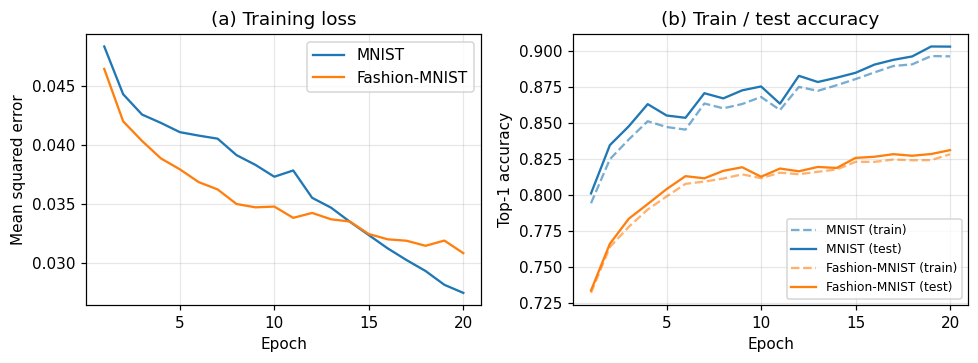

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for name, meta in DATASETS.items():
    h = load_history(name)
    axes[0].plot(h['epoch'], h['train_loss'], label=meta['label'], color=meta['color'])
    axes[1].plot(h['epoch'], h['train_acc'], '--', color=meta['color'], alpha=0.6,
                 label=f"{meta['label']} (train)")
    axes[1].plot(h['epoch'], h['test_acc'],  '-',  color=meta['color'],
                 label=f"{meta['label']} (test)")
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean squared error')
axes[0].set_title('(a) Training loss'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Top-1 accuracy')
axes[1].set_title('(b) Train / test accuracy'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_training_curves.pdf'))
plt.show()

## Figure 2 (primary): Accuracy vs. noise sigma

Mean +/- 1 std over `eval_seeds` independent noise draws per sigma. Steeper slope = more brittle.

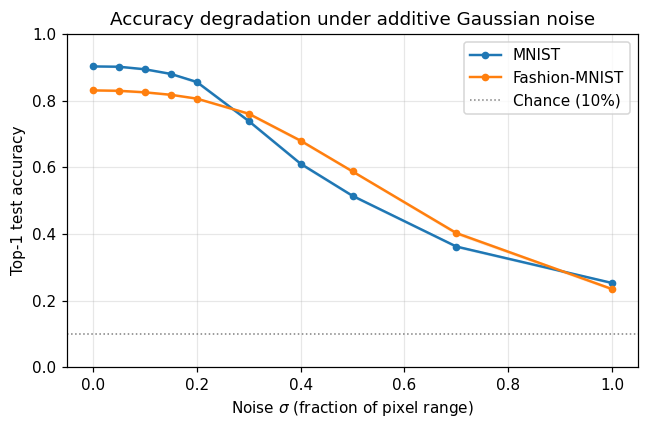

In [3]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
for name, meta in DATASETS.items():
    df = load_sweep(name)
    grouped = df.groupby('sigma')['accuracy'].agg(['mean', 'std']).reset_index()
    ax.plot(grouped['sigma'], grouped['mean'], '-o', color=meta['color'],
            label=meta['label'], linewidth=1.6, markersize=4)
    ax.fill_between(grouped['sigma'], grouped['mean'] - grouped['std'],
                    grouped['mean'] + grouped['std'], color=meta['color'], alpha=0.18)
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1, label='Chance (10%)')
ax.set_xlabel(r'Noise $\sigma$ (fraction of pixel range)')
ax.set_ylabel('Top-1 test accuracy')
ax.set_title('Accuracy degradation under additive Gaussian noise')
ax.set_ylim(0.0, 1.0); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig2_accuracy_vs_sigma.pdf'))
plt.show()

## Table I: Per-sigma accuracy with std

Numerical companion to Figure 2. The notebook prints a LaTeX-ready string that can be pasted into the report.

In [4]:
table = {}
for name, meta in DATASETS.items():
    df = load_sweep(name)
    g = df.groupby('sigma')['accuracy'].agg(['mean', 'std']).reset_index()
    table[meta['label']] = g.set_index('sigma')
combined = pd.concat({k: v for k, v in table.items()}, axis=1)
print(combined.round(4).to_string())
print()
print(combined.round(4).to_latex(float_format='%.4f'))

        MNIST         Fashion-MNIST        
         mean     std          mean     std
sigma                                      
0.00   0.9032  0.0000        0.8312  0.0000
0.05   0.9023  0.0008        0.8300  0.0013
0.10   0.8946  0.0011        0.8254  0.0012
0.15   0.8807  0.0008        0.8180  0.0010
0.20   0.8565  0.0026        0.8065  0.0008
0.30   0.7392  0.0026        0.7612  0.0026
0.40   0.6109  0.0028        0.6801  0.0028
0.50   0.5146  0.0021        0.5879  0.0020
0.70   0.3623  0.0019        0.4028  0.0031
1.00   0.2529  0.0014        0.2346  0.0022

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{MNIST} & \multicolumn{2}{r}{Fashion-MNIST} \\
 & mean & std & mean & std \\
sigma &  &  &  &  \\
\midrule
0.000000 & 0.9032 & 0.0000 & 0.8312 & 0.0000 \\
0.050000 & 0.9023 & 0.0008 & 0.8300 & 0.0013 \\
0.100000 & 0.8946 & 0.0011 & 0.8254 & 0.0012 \\
0.150000 & 0.8807 & 0.0008 & 0.8180 & 0.0010 \\
0.200000 & 0.8565 & 0.0026 & 0.8065 & 0.0008 \\
0.300000 & 0.7392 & 0.0026 

## Figure 3: Qualitative sample images at increasing sigma

Two rows per dataset (4 rows total) at sigma in {0, 0.1, 0.3, 0.5, 0.7, 1.0}.

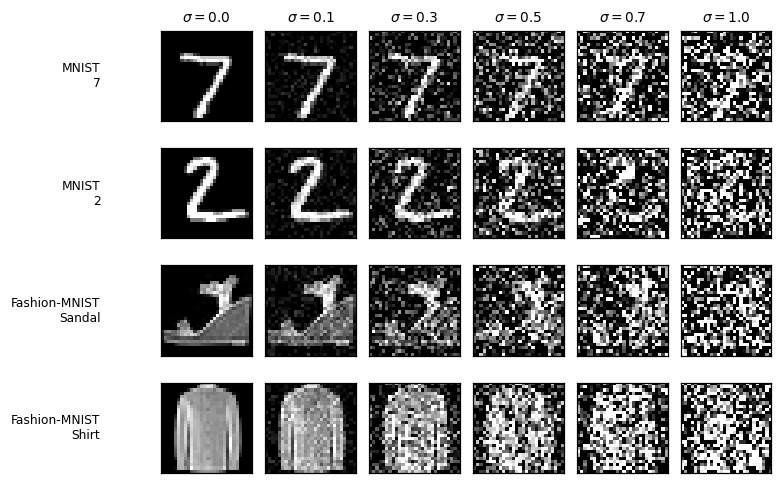

In [5]:
show_sigmas = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(4, len(show_sigmas), figsize=(1.2 * len(show_sigmas), 4.6))
row = 0
for name, meta in DATASETS.items():
    images, labels = load_samples(name)
    classes = MNIST_CLASSES if name == 'mnist' else FASHION_CLASSES
    for sub in range(2):
        idx = sub
        for col, sigma in enumerate(show_sigmas):
            local_rng = np.random.default_rng(100 * row + col)
            x = images[idx]
            x_noisy = np.clip(x + local_rng.normal(0, sigma, x.shape), 0, 1)
            ax = axes[row, col]
            ax.imshow(x_noisy.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(rf'$\sigma={sigma}$', fontsize=9)
            if col == 0:
                ax.set_ylabel(f"{meta['label']}\n{classes[labels[idx]]}",
                              fontsize=8, rotation=0, labelpad=40, va='center', ha='right')
        row += 1
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_sample_images.pdf'))
plt.show()

## Figure 4: Fashion-MNIST confusion matrices at sigma = 0 and sigma = 0.3

Reveals which classes collapse first under noise.

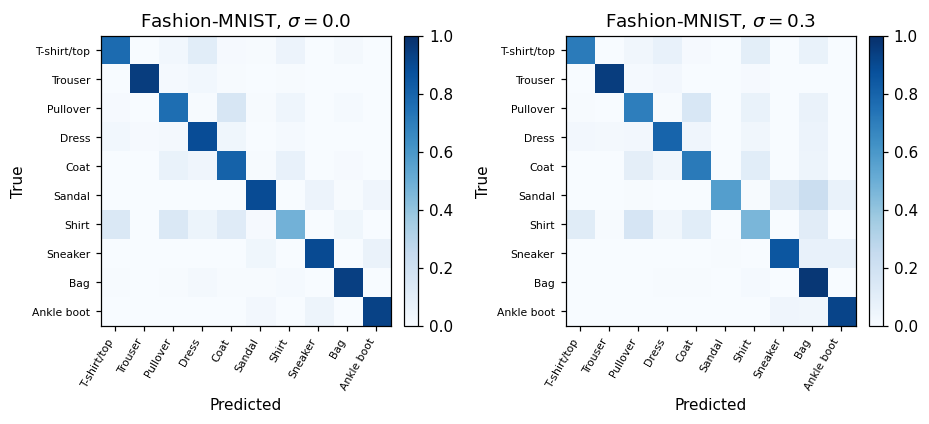

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8))
for ax, sigma in zip(axes, [0.0, 0.3]):
    cm = load_confusion('fashion', sigma)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(rf'Fashion-MNIST, $\sigma={sigma}$')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(FASHION_CLASSES, rotation=60, ha='right', fontsize=7)
    ax.set_yticklabels(FASHION_CLASSES, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_confusion_fashion.pdf'))
plt.show()

## Summary statistics for the body text

Prints the half-accuracy sigma (the noise level at which test accuracy first drops below 50%) and the slope of the degradation curve between sigma=0.1 and sigma=0.5 for each dataset.

In [7]:
for name, meta in DATASETS.items():
    df = load_sweep(name)
    g = df.groupby('sigma')['accuracy'].mean().reset_index()
    half = g[g['accuracy'] <= 0.5]
    sigma_half = float(half['sigma'].iloc[0]) if len(half) else float('nan')
    a01 = float(g.loc[(g['sigma'] - 0.1).abs().idxmin(), 'accuracy'])
    a05 = float(g.loc[(g['sigma'] - 0.5).abs().idxmin(), 'accuracy'])
    slope = (a05 - a01) / (0.5 - 0.1)
    print(f"{meta['label']:>14s}: half-accuracy sigma = {sigma_half:.2f} | "
          f"slope sigma in [0.1,0.5] = {slope:+.3f} per unit sigma")

         MNIST: half-accuracy sigma = 0.70 | slope sigma in [0.1,0.5] = -0.950 per unit sigma
 Fashion-MNIST: half-accuracy sigma = 0.70 | slope sigma in [0.1,0.5] = -0.594 per unit sigma
